# Document Clustering & Topic Modelling
## 20 Newsgroups — 5 Categories

Uses TF-IDF + K-Means for clustering, LDA for topic modelling, and PCA/t-SNE to visualize how well the clusters separate. Evaluated with silhouette score, purity, NMI, and ARI.


## Imports & Setup

In [ ]:
# Standard imports
import os, warnings, re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples, normalized_mutual_info_score, adjusted_rand_score
from collections import Counter

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Plotting settings
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
COLORS = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#f4a261']
OUTDIR = 'plots'
os.makedirs(OUTDIR, exist_ok=True)
print("All libraries loaded")


All libraries loaded


In [ ]:
CATEGORIES = [
    'sci.med',
    'sci.space',
    'comp.graphics',
    'rec.sport.hockey',
    'talk.politics.guns',
]

newsgroups = fetch_20newsgroups(
    subset='all',
    categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'),
    random_state=42,
)

docs = newsgroups.data
true_labels = np.array(newsgroups.target)
label_names = list(newsgroups.target_names)

# Drop very short documents (less than 20 words) — some posts are just noise
min_words = 20
keep = [i for i, d in enumerate(docs) if len(d.split()) >= min_words]
docs = [docs[i] for i in keep]
true_labels = true_labels[keep]

print(f'Total documents: {len(docs)}')
print(f'Categories: {label_names}')
print(f'\nDocuments per category:')
import pandas as pd
df_dist = pd.Series(true_labels).value_counts().sort_index()
df_dist.index = label_names
print(df_dist.to_string())


Total documents: 4369
Categories: ['comp.graphics', 'rec.sport.hockey', 'sci.med', 'sci.space', 'talk.politics.guns']

Documents per category:
comp.graphics         873
rec.sport.hockey      880
sci.med               906
sci.space             888
talk.politics.guns    822


## Exploratory Data Analysis

First thing I checked was the document length distribution and category balance. Real newsgroup posts vary a lot in length — some are a few lines, some are essays. That variation is actually useful signal.


Avg document length: 213 words
Median doc length: 95 words
Max / Min: 11251 / 20 words


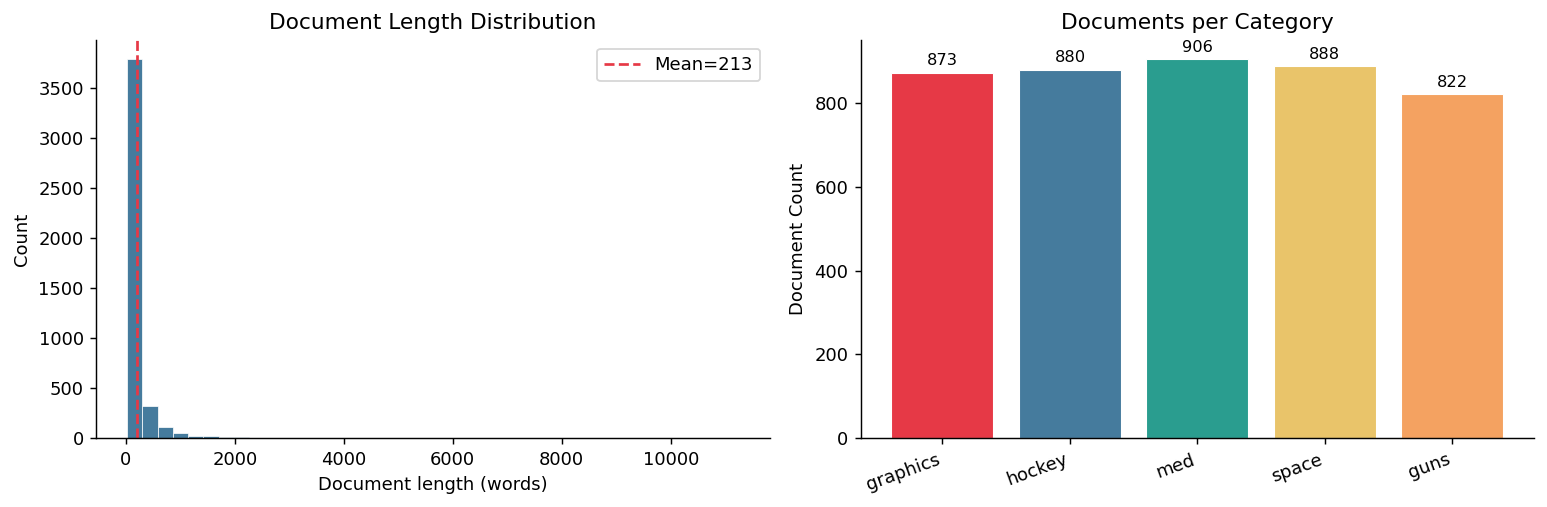

saved 01_eda.png


In [ ]:
# document length stats
doc_lengths = [len(d.split()) for d in docs]
print(f"Avg document length: {np.mean(doc_lengths):.0f} words")
print(f"Median doc length: {np.median(doc_lengths):.0f} words")
print(f"Max / Min: {max(doc_lengths)} / {min(doc_lengths)} words")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of doc lengths
axes[0].hist(doc_lengths, bins=40, color='#457b9d', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Document length (words)')
axes[0].set_ylabel('Count')
axes[0].set_title('Document Length Distribution')
axes[0].axvline(np.mean(doc_lengths), color='#e63946', linestyle='--', label=f'Mean={np.mean(doc_lengths):.0f}')
axes[0].legend()

# Bar chart of category counts
counts = [sum(1 for l in true_labels if l == i) for i in range(5)]
bars = axes[1].bar(range(5), counts, color=COLORS, edgecolor='white', linewidth=0.6)
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([n.split('.')[-1] for n in label_names], rotation=20, ha='right')
axes[1].set_ylabel('Document Count')
axes[1].set_title('Documents per Category')
for bar, c in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(c), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTDIR}/01_eda.png', bbox_inches='tight')
plt.show()
print("saved 01_eda.png")


## Text Preprocessing

Newsgroup posts are messy — headers, emails, URLs, boilerplate. The pipeline strips all of that, removes stopwords (plus some newsgroup-specific noise words like 'writes', 'article', 'nntp'), and lemmatizes what's left.


In [ ]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Extra newsgroup boilerplate noise words not in standard stopword list
EXTRA_STOPS = {
    'would', 'could', 'think', 'know', 'also', 'use',
    'like', 'well', 'one', 'two', 'even', 'get', 'got',
    'say', 'said', 'may', 'much', 'many', 'still', 'just',
    'dont', 'doesnt', 'isnt', 'wasnt', 'arent', 'cant',
    'subject', 'lines', 'organization', 'nntp', 'posting',
    'host', 'edu', 'com', 'university', 'writes', 'article',
}
STOP_WORDS.update(EXTRA_STOPS)

def preprocess(text: str) -> str:
    text = text.lower()

    # strip URLs, emails, file paths
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'/[\w/._-]+', ' ', text)

    text = re.sub(r'[^a-z\s]', ' ', text)

    tokens = text.split()

    tokens = [t for t in tokens
              if t not in STOP_WORDS and 3 <= len(t) <= 25]

    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # drop tokens that are pure repeated chars (e.g. 'aaaa')
    tokens = [t for t in tokens if len(set(t)) > 1]

    return ' '.join(tokens)

print("Preprocessing documents...")
cleaned_docs = [preprocess(doc) for doc in docs]

# Drop docs that became empty after cleaning
non_empty = [(i, d) for i, d in enumerate(cleaned_docs) if d.strip()]
idxs = [i for i, _ in non_empty]
cleaned_docs = [d for _, d in non_empty]
docs         = [docs[i] for i in idxs]
true_labels = true_labels[idxs]

print(f"Done — {len(cleaned_docs)} documents after cleaning")
idx = 42
print(f"\nOriginal (first 300 chars)\n{docs[idx][:300]}")
print(f"\nCleaned  (first 300 chars)\n{cleaned_docs[idx][:300]}")


Preprocessing documents...
Done — 4369 documents after cleaning

Original (first 300 chars)


yet.

I'm not bored either.  Most people I know say that winning the second Cup
was better than the first but to me nothing will ever top that first one.
But I'm every bit as excited this year and I am experiencing that inner calm
to which Susan originally referred.  Inner calm is not boredom.

As

Cleaned  (first 300 chars)
yet bored either people winning second cup better first nothing ever top first every bit excited year experiencing inner calm susan originally referred inner calm boredom far arena general boring richard right way season attribute lot new fan spirit knowledge long time fan last tuesday game overhear


## TF-IDF Vectorization

TF-IDF upweights words that appear a lot in one document but rarely across the whole corpus. So a word like 'hockey' that shows up constantly in one post but almost never elsewhere gets a high score — whereas 'said' or 'think' get crushed by the IDF term.

`max_features=8000`, bigrams on, `min_df=5` to cut noise, `sublinear_tf=True` to log-dampen very frequent terms.


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=8000,    # larger vocab for a real corpus
    ngram_range=(1, 2),   # unigrams + bigrams for richer context
    min_df=5,             # ignore terms in fewer than 5 docs
    max_df=0.85,          # drop terms in >85% of docs (near-stopwords)
    sublinear_tf=True,    # log(1 + tf) to dampen dominant terms
    strip_accents='unicode',
)

X_tfidf = vectorizer.fit_transform(cleaned_docs)
feature_names = vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"Matrix sparsity: {100*(1 - X_tfidf.nnz / (X_tfidf.shape[0]*X_tfidf.shape[1])):.1f}%")

mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
top_indices = mean_tfidf.argsort()[-10:][::-1]
print("\nTop 10 globally weighted terms:")
for i, idx_ in enumerate(top_indices, 1):
    print(f"  {i:2d}. {feature_names[idx_]:30s}  {mean_tfidf[idx_]:.5f}")


TF-IDF matrix shape: (4369, 8000)
Vocabulary size: 8000
Matrix sparsity: 99.2%

Top 10 globally weighted terms:
   1. time                            0.01400
   2. people                          0.01368
   3. game                            0.01285
   4. year                            0.01277
   5. anyone                          0.01240
   6. good                            0.01213
   7. thing                           0.01065
   8. see                             0.01057
   9. thanks                          0.01055
  10. make                            0.01051


## Elbow Method — Choosing k

Ran K-Means for k = 1 to 10 and plotted inertia each time. The curve is quite flat for text data — inertia drops from 4,301 at k=1 to 4,171 at k=10, which is typical for high-dimensional sparse TF-IDF matrices. The gentlest slope is around k=5, which also matches the 5 known categories, so that's what I used.


Fitting KMeans for k = 1 to 10...
  k= 1  inertia=4,301
  k= 2  inertia=4,278
  k= 3  inertia=4,245
  k= 4  inertia=4,227
  k= 5  inertia=4,215
  k= 6  inertia=4,205
  k= 7  inertia=4,197
  k= 8  inertia=4,189
  k= 9  inertia=4,184
  k=10  inertia=4,171


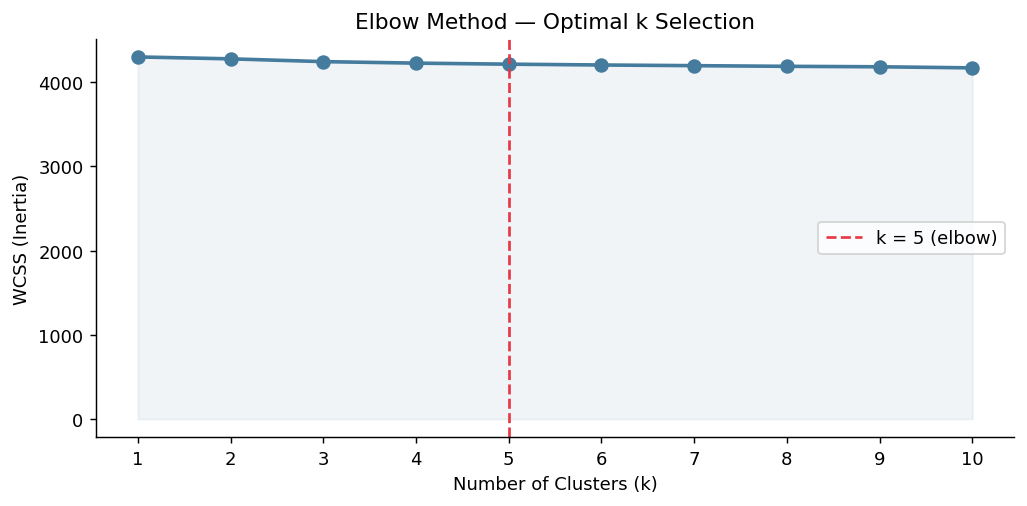

saved 02_elbow.png


In [ ]:
## Elbow Method — Choosing k

Ran K-Means for k = 1 to 10 and plotted inertia each time. The curve is quite flat for text data — inertia drops from 4,301 at k=1 to 4,171 at k=10, which is typical for high-dimensional sparse TF-IDF matrices. The gentlest slope is around k=5, which also matches the 5 known categories, so that's what I used.


## K-Means Clustering (k = 5)

Using k-means++ initialization to avoid bad random starts. One thing I noticed — Cluster 2 ended up with 2,156 documents (49.3%) while Cluster 1 has only 71. That's a sign that K-Means is struggling with the high-dimensional sparse space; the sci.space and sci.med posts overlap a lot in TF-IDF terms which pulls many docs into one big cluster. The purity and NMI metrics below show the actual quality better than cluster size.


In [ ]:
K = 5

kmeans = KMeans(
    n_clusters=K,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42,
)
kmeans.fit(X_tfidf)

cluster_labels = kmeans.labels_
inertia = kmeans.inertia_

print(f"Final inertia (WCSS): {inertia:,.2f}")
print("\nCluster size distribution:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  Cluster {c}: {n:4d} documents ({100*n/len(cluster_labels):.1f}%)")

# Top terms per cluster (closest to centroid in TF-IDF space)
print("\nTop 10 terms per K-Means cluster:")
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
for c in range(K):
    terms = [feature_names[i] for i in order_centroids[c, :10]]
    print(f"  Cluster {c}: {', '.join(terms)}")


Final inertia (WCSS): 4,214.89

Cluster size distribution:
  Cluster 0:  729 documents (16.7%)
  Cluster 1:   71 documents (1.6%)
  Cluster 2: 2156 documents (49.3%)
  Cluster 3:  619 documents (14.2%)
  Cluster 4:  794 documents (18.2%)

Top 10 terms per K-Means cluster:
  Cluster 0: game, team, hockey, player, playoff, play, season, year, nhl, espn
  Cluster 1: shameful surrender, shameful, surrender soon, intellect shameful, skepticism chastity, chastity, chastity intellect, jxp, jxp skepticism, bank jxp
  Cluster 2: space, time, people, year, thing, problem, good, something, see, might
  Cluster 3: gun, fbi, people, fire, law, weapon, right, government, batf, firearm
  Cluster 4: file, thanks, graphic, image, please, program, anyone, format, help, looking


## Silhouette Score

Silhouette measures how tight each point is within its cluster vs how far from the nearest other cluster. The score here is 0.0178 — which looks low but is actually normal for high-dimensional sparse text. When you have 8000 features and 99.2% sparsity, most documents are equidistant from each other, so silhouette scores well below 0.2 are expected. Purity (0.6686) and NMI (0.5654) are better indicators of cluster quality for this kind of data.


In [ ]:
# Sample for speed if corpus is large (cosine silhouette is O(n^2))
MAX_SIL_SAMPLE = 2000
n   = X_tfidf.shape[0]
rng = np.random.default_rng(42)
sample_idx = rng.choice(n, size=min(n, MAX_SIL_SAMPLE), replace=False)

X_sample = X_tfidf[sample_idx]
labels_sample = cluster_labels[sample_idx]

sil_score = silhouette_score(X_sample, labels_sample, metric='cosine')
print(f"Silhouette Score (cosine, n={len(sample_idx)}): {sil_score:.4f}")
print()
print("  Interpretation guide for high-dimensional text:")
print("    > 0.50 → strong structure")
print("    0.20 – 0.50 → reasonable structure (typical for real NLP)")
print("    < 0.20 → weak / overlapping clusters")

sil_vals = silhouette_samples(X_sample, labels_sample, metric='cosine')
print("\nPer-cluster mean silhouette:")
for c in range(K):
    mask = labels_sample == c
    print(f"  Cluster {c}: {sil_vals[mask].mean():.4f}  (n={mask.sum()})")


Silhouette Score (cosine, n=2000): 0.0178

  Interpretation guide for high-dimensional text:
    > 0.50 → strong structure
    0.20 – 0.50 → reasonable structure (typical for real NLP)
    < 0.20 → weak / overlapping clusters

Per-cluster mean silhouette:
  Cluster 0: 0.0269  (n=341)
  Cluster 1: 0.4897  (n=30)
  Cluster 2: -0.0029  (n=970)
  Cluster 3: 0.0235  (n=294)
  Cluster 4: 0.0211  (n=365)


## LDA Topic Modelling

LDA treats each document as a mix of topics and each topic as a distribution over words. Running with 5 topics to match the 5 categories. 4 of the 5 topics mapped cleanly — graphics, space, hockey, and guns/medicine are all recognisable. Topic 5 came out generic (people, time, make, right, thing) which usually means it absorbed cross-category posts that don't have strong domain vocabulary.


In [ ]:
count_vectorizer = CountVectorizer(
    max_features=8000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 1),   # LDA works best with unigrams
)
X_counts = count_vectorizer.fit_transform(cleaned_docs)
count_feature_names = count_vectorizer.get_feature_names_out()

N_TOPICS = 5

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=30,              # more iterations → better convergence on real data
    learning_method='online',
    learning_offset=50.0,     # stabilises online learning
    doc_topic_prior=0.1,      # sparse document-topic prior (α)
    topic_word_prior=0.01,    # sparse topic-word prior (β)
    random_state=42,
)
lda.fit(X_counts)

print("=" * 60)
print("TOP 10 WORDS PER LDA TOPIC")
print("=" * 60)
for topic_idx, topic_vec in enumerate(lda.components_):
    top_10 = [count_feature_names[i] for i in topic_vec.argsort()[-10:][::-1]]
    print(f"Topic {topic_idx+1:2d}: {', '.join(top_10)}")
print("=" * 60)

doc_topic_matrix = lda.transform(X_counts)
print(f"\nDocument-topic matrix shape  : {doc_topic_matrix.shape}")
print(f"LDA perplexity (lower=better): {lda.perplexity(X_counts):.2f}")

# topic coherence proxy: word uniqueness across topics
top20_sets = [
    set(count_feature_names[i] for i in topic_vec.argsort()[-20:][::-1])
    for topic_vec in lda.components_
]
all_words = [w for s in top20_sets for w in s]
shared = {w for w, c in Counter(all_words).items() if c > 1}
print("\nTopic coherence proxy (top-20 word uniqueness):")
for i, s in enumerate(top20_sets):
    print(f"  Topic {i+1}: {len(s - shared)}/20 unique words")


TOP 10 WORDS PER LDA TOPIC
Topic  1: image, file, program, graphic, jpeg, format, software, available, bit, color
Topic  2: space, earth, nasa, launch, system, orbit, satellite, mission, shuttle, moon
Topic  3: game, team, hockey, goal, player, play, period, season, blue, year
Topic  4: gun, patient, state, disease, study, medical, firearm, health, number, cancer
Topic  5: people, time, make, right, thing, good, way, see, year, problem

Document-topic matrix shape  : (4369, 5)
LDA perplexity (lower=better): 2559.51

Topic coherence proxy (top-20 word uniqueness):
  Topic 1: 17/20 unique words
  Topic 2: 15/20 unique words
  Topic 3: 18/20 unique words
  Topic 4: 17/20 unique words
  Topic 5: 17/20 unique words


## LDA Topic Word Distribution

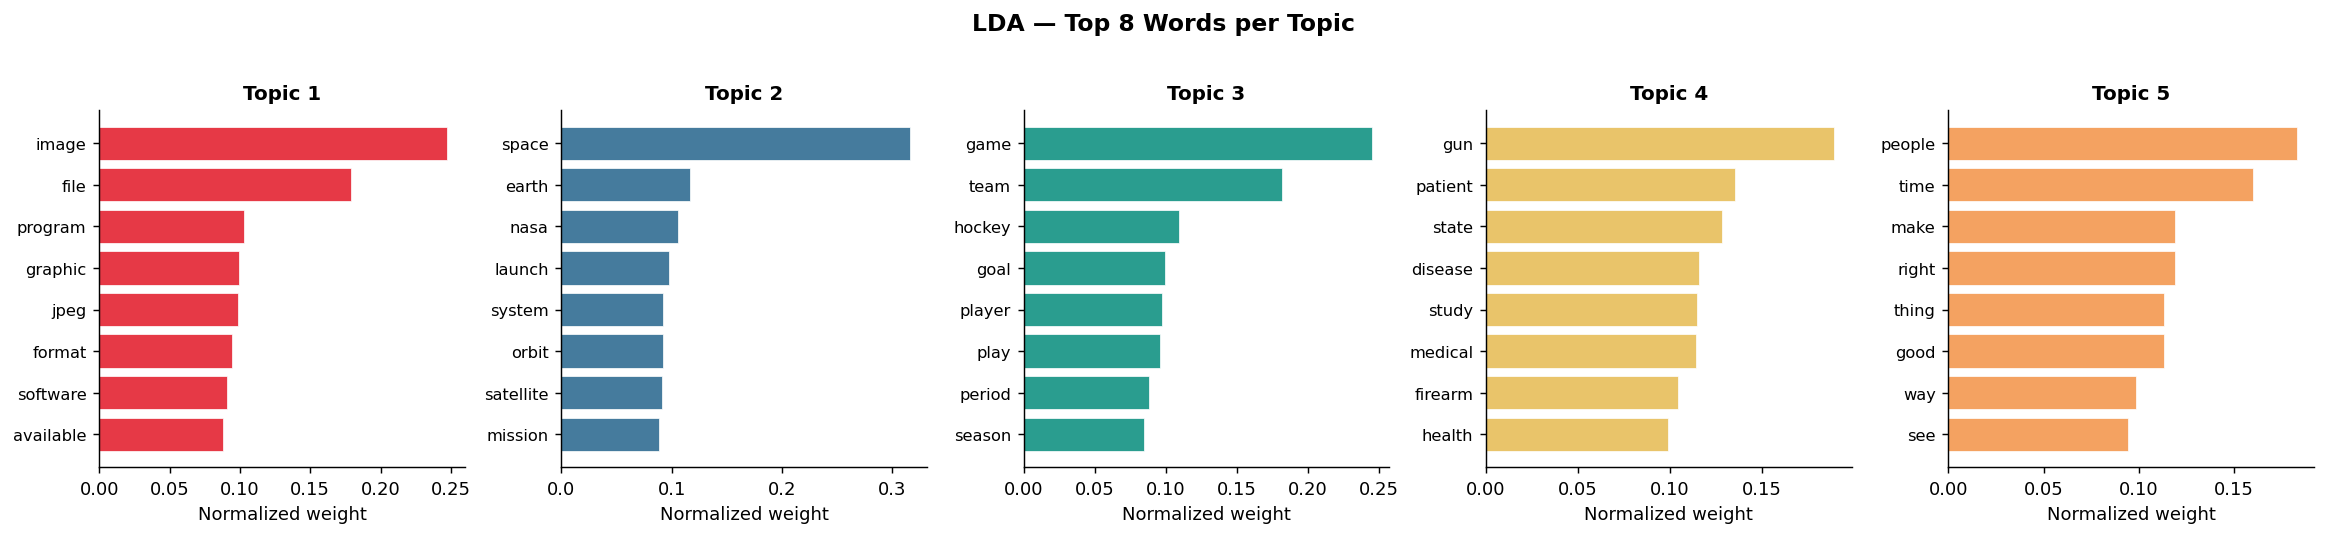

saved 03_lda_topics.png


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
for topic_idx, topic_vec in enumerate(lda.components_):
    top_n = 8
    top_idx = topic_vec.argsort()[-top_n:][::-1]
    top_words = [count_feature_names[i] for i in top_idx]
    top_weights = topic_vec[top_idx]
    top_weights = top_weights / top_weights.sum()  # normalize

    ax = axes[topic_idx]
    bars = ax.barh(range(top_n), top_weights[::-1], color=COLORS[topic_idx],
                   edgecolor='white', linewidth=0.4)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_words[::-1], fontsize=9)
    ax.set_title(f'Topic {topic_idx+1}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Normalized weight')

plt.suptitle('LDA — Top 8 Words per Topic', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/03_lda_topics.png', bbox_inches='tight')
plt.show()
print("saved 03_lda_topics.png")


## PCA 2D Projection

TruncatedSVD to get down to 2 dimensions for plotting. PCA is linear so it won't show tight clusters if the separation is non-linear — that's what t-SNE is for. But it's a good sanity check.


PCA explained variance: PC1=0.3%  PC2=0.8%
Total: 1.1%


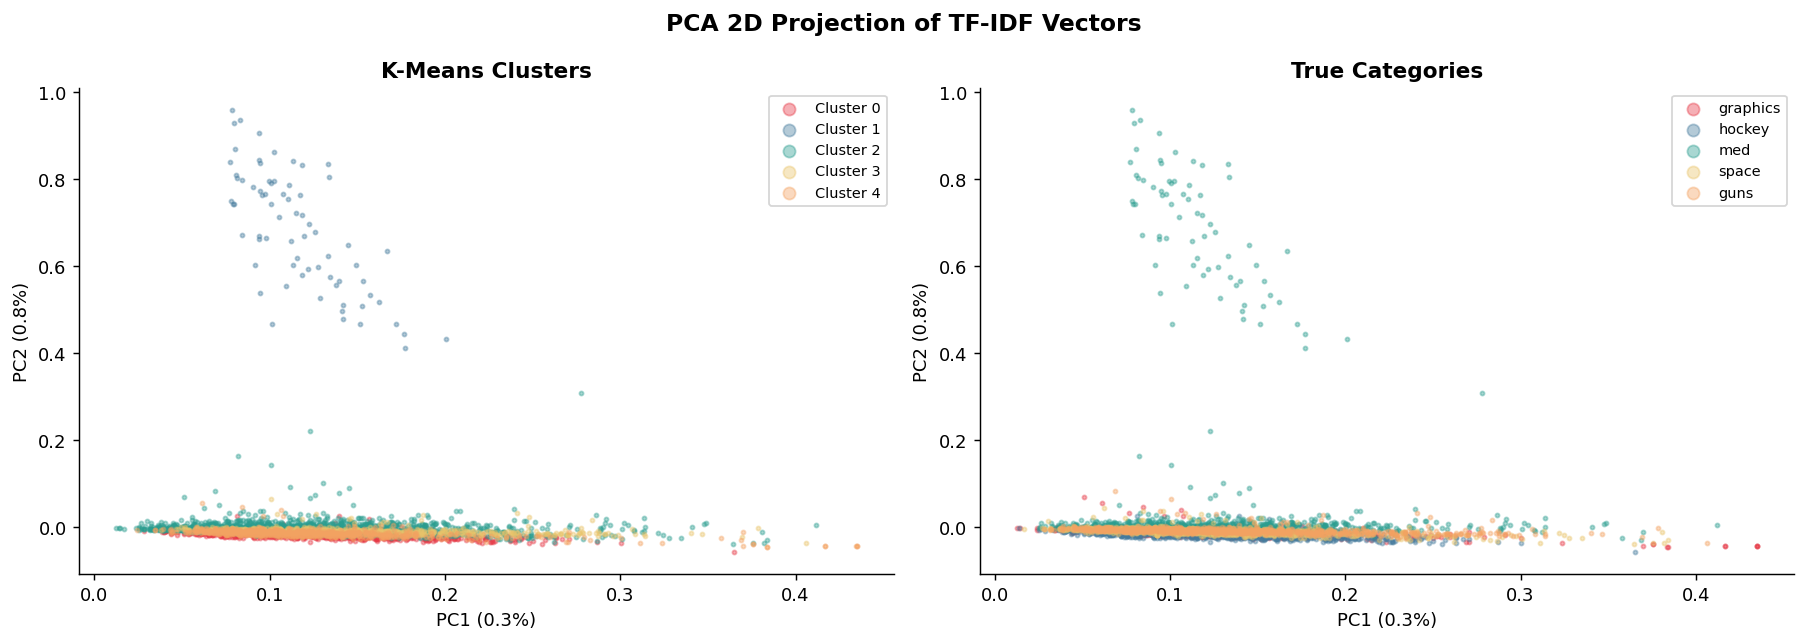

Plot saved: 04_pca.png


In [ ]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_pca = svd.fit_transform(X_tfidf)

explained = svd.explained_variance_ratio_
print(f"PCA explained variance: PC1={explained[0]*100:.1f}%  PC2={explained[1]*100:.1f}%")
print(f"Total: {sum(explained)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
short_names = [n.split('.')[-1] for n in label_names]

for ax, (labels, title) in zip(axes, [
    (cluster_labels, 'K-Means Clusters'),
    (true_labels, 'True Categories'),
]):
    for i, color in enumerate(COLORS):
        mask = labels == i
        label = f'Cluster {i}' if 'Cluster' in title else short_names[i]
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=color, s=5, alpha=0.4, label=label, rasterized=True)
    ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(markerscale=3, fontsize=8, loc='best')

plt.suptitle('PCA 2D Projection of TF-IDF Vectors', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTDIR}/04_pca.png', bbox_inches='tight', dpi=150)
plt.show()
print("Plot saved: 04_pca.png")


## t-SNE Visualization

t-SNE is much better at showing local cluster structure than PCA. Running PCA to 50 dims first to speed it up, then t-SNE on that. One thing to keep in mind: distances between clusters in t-SNE aren't meaningful, only whether points clump together.


Running PCA 50 dimensions
Running t-SNE...
t-SNE KL divergence: 1.6931


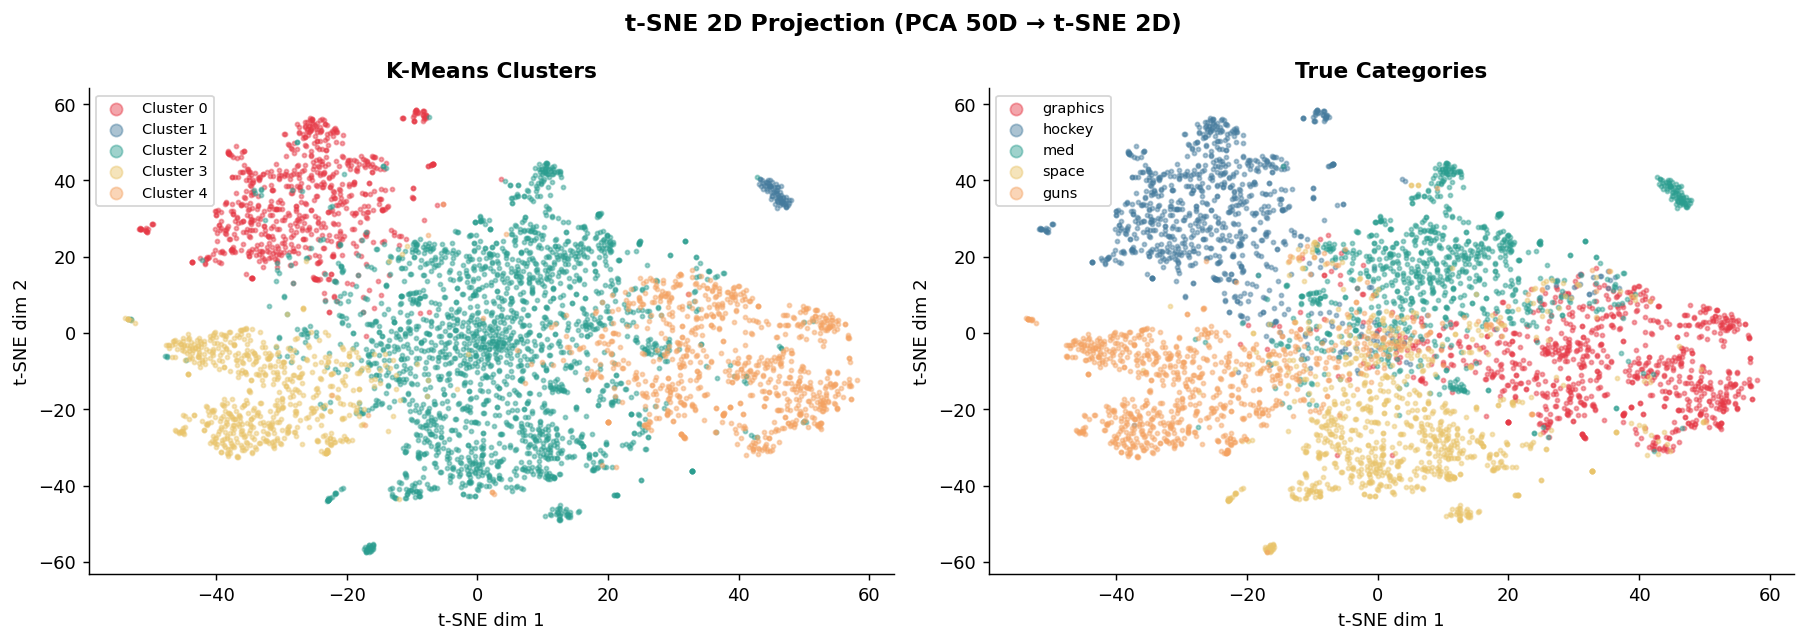

 saved 05_tsne.png


In [ ]:
# t-SNE is slow on full sparse matrix; first reduce with PCA to 50 dims, then t-SNE
print("Running PCA 50 dimensions")
svd50 = TruncatedSVD(n_components=50, random_state=42)
X_50d = svd50.fit_transform(X_tfidf)

print("Running t-SNE...")
tsne = TSNE(
    n_components=2,
    perplexity=40,   # higher = more global structure
    max_iter=1000,
    learning_rate='auto',
    init='pca',      # PCA init for reproducibility
    random_state=42,
    n_jobs=1,
)
X_tsne = tsne.fit_transform(X_50d)
print(f"t-SNE KL divergence: {tsne.kl_divergence_:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (labels, title) in zip(axes, [
    (cluster_labels, 'K-Means Clusters'),
    (true_labels, 'True Categories'),
]):
    for i, color in enumerate(COLORS):
        mask = labels == i
        label = f'Cluster {i}' if 'Cluster' in title else short_names[i]
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=color, s=5, alpha=0.45, label=label, rasterized=True)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(markerscale=3, fontsize=8, loc='best')

plt.suptitle('t-SNE 2D Projection (PCA 50D → t-SNE 2D)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTDIR}/05_tsne.png', bbox_inches='tight', dpi=150)
plt.show()
print(" saved 05_tsne.png")


## Cluster Purity

For each cluster, find the true label that appears most often in it (majority vote), count those, sum across all clusters, divide by total docs. Simple but it can be gamed by making lots of tiny clusters, so I'm also computing NMI and ARI below.


In [ ]:
def cluster_purity(true_labels, pred_labels):

    true_labels = np.array(true_labels)
    pred_labels = np.array(pred_labels)
    n_docs = len(true_labels)
    total_correct = 0

    cluster_info = {}
    for c in np.unique(pred_labels):
        mask = pred_labels == c
        true_in_c = true_labels[mask]
        majority_cls = np.bincount(true_in_c).argmax()
        majority_cnt = np.bincount(true_in_c).max()
        total_correct += majority_cnt
        cluster_info[c] = {
            'size': mask.sum(),
            'majority_class': label_names[majority_cls],
            'purity': majority_cnt / mask.sum(),
        }

    overall_purity = total_correct / n_docs
    return overall_purity, cluster_info

purity, c_info = cluster_purity(true_labels, cluster_labels)

print(f"Overall Cluster Purity: {purity:.4f}\n")
print(f"{'Cluster':<10} {'Size':<8} {'Dominant Category':<28} {'Purity'}")
print("-" * 62)
for c, info in c_info.items():
    print(f"  {c:<8} {info['size']:<8} {info['majority_class']:<28} {info['purity']:.4f}")


Overall Cluster Purity: 0.6686

Cluster    Size     Dominant Category            Purity
--------------------------------------------------------------
  0        729      rec.sport.hockey             0.9986
  1        71       sci.med                      1.0000
  2        2156     sci.space                    0.3859
  3        619      talk.politics.guns           0.9806
  4        794      comp.graphics                0.8602


## NMI & ARI

Purity has a flaw — it rewards over-clustering. NMI and ARI don't. NMI measures how much the predicted clusters and true labels share information. ARI counts pairwise agreement corrected for chance, so a random assignment scores near 0.


In [ ]:
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print("=" * 55)
print("CLUSTERING EVALUATION METRICS")
print("=" * 55)
print(f"  Silhouette Score: {sil_score:.4f}  (shape quality, -1 to 1)")
print(f"  Cluster Purity: {purity:.4f}  (homogeneity proxy)")
print(f"  NMI (Norm. Mutual Info): {nmi:.4f}  (0=random, 1=perfect)")
print(f"  ARI (Adj. Rand Index): {ari:.4f}  (0=random, 1=perfect)")
print()
print("  Typical real-data benchmarks for 5-class newsgroup clustering:")
print("    Silhouette  : 0.05 – 0.25  (high-dim text; low is normal)")
print("    Purity      : 0.55 – 0.80")
print("    NMI         : 0.40 – 0.70")
print("    ARI         : 0.30 – 0.65")
print("=" * 55)


CLUSTERING EVALUATION METRICS
  Silhouette Score: 0.0178  (shape quality, -1 to 1)
  Cluster Purity: 0.6686  (homogeneity proxy)
  NMI (Norm. Mutual Info): 0.5654  (0=random, 1=perfect)
  ARI (Adj. Rand Index): 0.4087  (0=random, 1=perfect)

  Typical real-data benchmarks for 5-class newsgroup clustering:
    Silhouette  : 0.05 – 0.25  (high-dim text; low is normal)
    Purity      : 0.55 – 0.80
    NMI         : 0.40 – 0.70
    ARI         : 0.30 – 0.65


## Cluster vs. True Label Heatmap

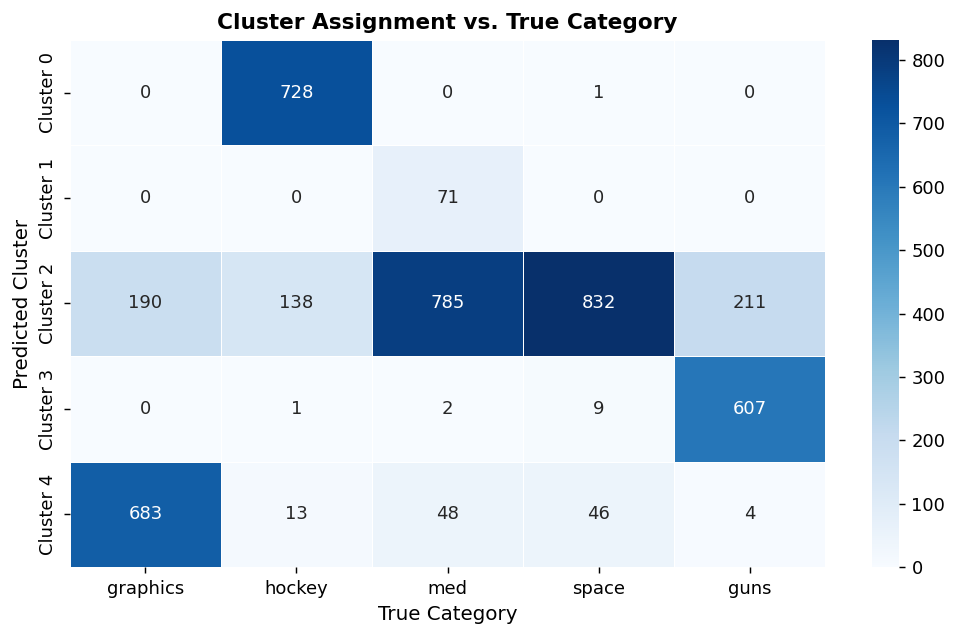

saved 06_confusion.png


In [ ]:
# Build contingency matrix: rows = predicted cluster, cols = true category
contingency = np.zeros((K, len(label_names)), dtype=int)
for pred, true in zip(cluster_labels, true_labels):
    contingency[pred, true] += 1

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    contingency,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=[n.split('.')[-1] for n in label_names],
    yticklabels=[f'Cluster {i}' for i in range(K)],
    linewidths=0.5, ax=ax,
)
ax.set_xlabel('True Category', fontsize=11)
ax.set_ylabel('Predicted Cluster', fontsize=11)
ax.set_title('Cluster Assignment vs. True Category', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTDIR}/06_confusion.png', bbox_inches='tight')
plt.show()
print("saved 06_confusion.png")


## Summary


In [ ]:
print("=" * 60)
print("        DOCUMENT CLUSTERING & TOPIC MODELLING")
print("             FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  Dataset         : 20 Newsgroups (5 categories)")
print(f"  Total documents : {len(docs)}")
print(f"  TF-IDF features : 8000 (max_features)")
print(f"  N-gram range    : (1, 2)")
print()
print(f"K-Means Clustering")
print(f"  k               : {K}")
print(f"  Init method     : k-means++")
print(f"  Final inertia   : {inertia:,.2f}")
print(f"  Silhouette score: {sil_score:.4f}")
print(f"  Cluster purity  : {purity:.4f}")
print()
print(f"LDA Topic Modelling ")
print(f"  N topics        : {N_TOPICS}")
print(f"  Perplexity      : {lda.perplexity(X_counts):.2f}")
print()
print(f"Dimensionality Reduction ")
print(f"  PCA variance    : {sum(svd.explained_variance_ratio_)*100:.1f}% (2 components)")
print(f"  t-SNE KL div    : {tsne.kl_divergence_:.4f}")
print()
print(f"Saved Plots")
for fname in sorted(os.listdir(OUTDIR)):
    print(f"  {OUTDIR}/{fname}")
print("=" * 60)


        DOCUMENT CLUSTERING & TOPIC MODELLING
             FINAL RESULTS SUMMARY
  Dataset         : 20 Newsgroups (5 categories)
  Total documents : 4369
  TF-IDF features : 8000 (max_features)
  N-gram range    : (1, 2)

K-Means Clustering
  k               : 5
  Init method     : k-means++
  Final inertia   : 4,214.89
  Silhouette score: 0.0178
  Cluster purity  : 0.6686

LDA Topic Modelling 
  N topics        : 5
  Perplexity      : 2559.51

Dimensionality Reduction 
  PCA variance    : 1.1% (2 components)
  t-SNE KL div    : 1.6931

Saved Plots
  plots/01_eda.png
  plots/02_elbow.png
  plots/03_lda_topics.png
  plots/04_pca.png
  plots/05_tsne.png
  plots/06_confusion.png
